# Hotel Booking Project Notebook

## 1. Importación de librerías necesarias
Importación de las librerías pandas, numpy, matplotlib y seaborn para el análisis y visualización de datos.

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Carga del archivo CSV

In [28]:
file_path = "../data/raw/hotel_booking.csv"
df = pd.read_csv(file_path)

## 3. Primera exploración

### 3.1 Visualización las primeras filas del dataset
Muestra de las primeras filas del DataFrame usando head() para obtener una vista general de los datos.

In [29]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Transient,98.0,0,1,Check-Out,2015-07-03,Linda Hines,LHines@verizon.com,713-226-5883,************5498


### 3.2 Exploración de la información general del dataset

In [30]:
print("El dataset tiene un tamaño de:", df.shape)

El dataset tiene un tamaño de: (119390, 36)


In [31]:
print(
    "La información sobre el tipo de las columnas, valores nulos y uso de la memoria es:"
)
df.info()

La información sobre el tipo de las columnas, valores nulos y uso de la memoria es:
<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 36 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babie

### 3.3 Descripción de las variables numéricas y categóricas

In [32]:
print("La descripción de las variables numéricas es:")
df.describe().T

La descripción de las variables numéricas es:


,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


In [33]:
print("La descripción de las variables categóricas es:")
df.describe(include="object").T

La descripción de las variables categóricas es:


C:\Users\midef\AppData\Local\Temp\ipykernel_11404\3624410489.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object").T


,count,unique,top,freq
hotel,119390,2,City Hotel,79330
arrival_date_month,119390,12,August,13877
meal,119390,5,BB,92310
country,118902,177,PRT,48590
market_segment,119390,8,Online TA,56477
distribution_channel,119390,5,TA/TO,97870
reserved_room_type,119390,10,A,85994
assigned_room_type,119390,12,A,74053
deposit_type,119390,3,No Deposit,104641
customer_type,119390,4,Transient,89613


## 4. Data Cleaning

### 4.1 Eliminar columnas irrelevantes

Estas columnas son sintéticas y no aportan valor analítico:

- name
- email
- phone-number
- credit_card


In [34]:
cols_to_drop = ["name", "email", "phone-number", "credit_card"]

df = df.drop(columns=cols_to_drop)

### 4.2 Valores nulos y columnas duplicadas

- En 'company' hay muchos nulos porque la mayoría de reservas NO son corporativas.
- En 'agent' los nulos se representan como reservas directas.
- En 'country' se desconoce el país.
- En 'children' hay muy pocos nulos. Imputación sencilla a 0.

In [35]:
print("Valores nulos: \n", df.isnull().sum().sort_values(ascending=False))

print("\nColumnas duplicadas:", df.duplicated().sum())

Valores nulos: 
 company                           112593
agent                              16340
country                              488
children                               4
arrival_date_month                     0
arrival_date_week_number               0
hotel                                  0
is_canceled                            0
stays_in_weekend_nights                0
arrival_date_day_of_month              0
adults                                 0
stays_in_week_nights                   0
babies                                 0
meal                                   0
lead_time                              0
arrival_date_year                      0
distribution_channel                   0
market_segment                         0
previous_bookings_not_canceled         0
is_repeated_guest                      0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
previous_cancellations                 0

### 4.3 Tratamiento de nulos 

In [36]:
df["children"] = df["children"].fillna(0)
df["company"] = df["company"].fillna(0)
df["agent"] = df["agent"].fillna(0)
df["country"] = df["country"].fillna("Unknown")

### 4.4 Duplicados
Debido a la ausencia de un identificador único de reserva, los registros duplicados podrían representar reservas reales con características similares. Por eso, no se eliminan los duplicados automáticamente.

In [37]:
print("El número de columnas duplicadas es de:", df.duplicated().sum())

El número de columnas duplicadas es de: 31994


### 4.5 Ajustes en ADR
Se ha observado un valor negativo de ADR y un valor extremo a recortar (winsorizing).

In [76]:
df = df[df["adr"] >= 0]
df["adr"] = df["adr"].clip(0, 600)

## 5. Conversión de tipos

In [38]:
df["arrival_date"] = pd.to_datetime(
    df["arrival_date_year"].astype(str)
    + "-"
    + df["arrival_date_month"]
    + "-"
    + df["arrival_date_day_of_month"].astype(str)
)

cat_cols = [
    "hotel",
    "meal",
    "market_segment",
    "distribution_channel",
    "deposit_type",
    "customer_type",
]

for col in cat_cols:
    df[col] = df[col].astype("category")

## 6. Feature engineering

### 6.1 Total nights

In [39]:
df["total_nights"] = df["stays_in_weekend_nights"] + df["stays_in_week_nights"]

### 6.2 Total guests

In [40]:
df["total_guests"] = df["adults"] + df["children"] + df["babies"]

### 6.3 Booking origin

In [41]:
conditions = [
    (df["company"] != 0) & (df["agent"] == 0),
    (df["company"] == 0) & (df["agent"] != 0),
]

choices = ["Company", "Travel Agency"]

df["booking_origin"] = np.select(conditions, choices, default="Direct")

### 6.4 Room changed

In [ ]:
df["room_changed"] = df["reserved_room_type"].astype(str) != df[
    "assigned_room_type"
].astype(str)

14917


### 6.5 Family booking

In [ ]:
df["is_family"] = (df["children"] > 0) | (df["babies"] > 0)

9332


### 6.6 Total stay cost

In [46]:
df["total_stay_cost"] = df["adr"] * df["total_nights"]

### 6.7 Long stay

In [47]:
df["is_long_stay"] = df["total_nights"] >= 7

### 6.8 Lead time category

In [48]:
df["lead_time_category"] = pd.cut(
    df["lead_time"],
    bins=[-1, 7, 30, 90, 365, 800],
    labels=["Very Short", "Short", "Medium", "Long", "Very Long"],
)

### 6.9 ADR category

In [49]:
df["adr_category"] = pd.qcut(df["adr"], q=4, labels=["Low", "Medium", "High", "Luxury"])

### 6.10 Season

In [50]:
def get_season(month):

    if month in [12, 1, 2]:
        return "Winter"

    elif month in [3, 4, 5]:
        return "Spring"

    elif month in [6, 7, 8]:
        return "Summer"

    return "Autumn"


df["arrival_month_num"] = df["arrival_date"].dt.month

df["season"] = df["arrival_month_num"].apply(get_season)

## 7. Análisis univariado de variables numéricas
### Cancelaciones

is_canceled
0    62.96
1    37.04
Name: proportion, dtype: float64


C:\Users\midef\AppData\Local\Temp\ipykernel_11404\4293446130.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


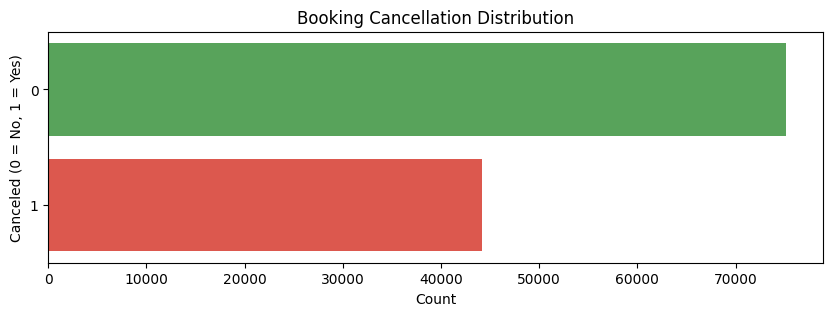

In [109]:
print(df["is_canceled"].value_counts(normalize=True).mul(100).round(2))

plt.figure(figsize=(10, 3))

sns.countplot(data=df, y="is_canceled", palette=["#4CAF50", "#F44336"])
plt.title("Booking Cancellation Distribution")
plt.ylabel("Canceled (0 = No, 1 = Yes)")
plt.xlabel("Count")
plt.show()

### Lead time

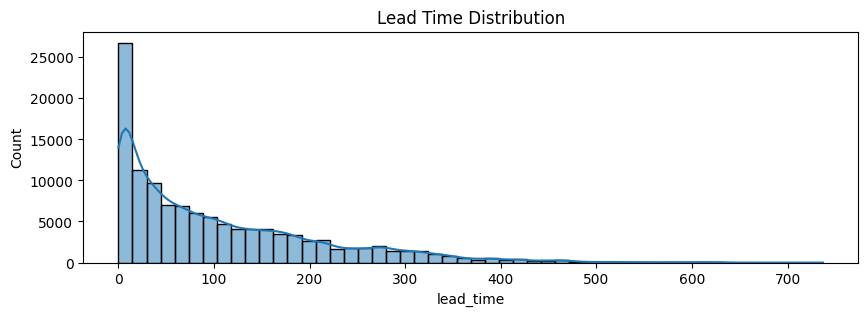

In [107]:
plt.figure(figsize=(10, 3))

sns.histplot(df["lead_time"], bins=50, kde=True)

plt.title("Lead Time Distribution")
plt.show()

### ADR

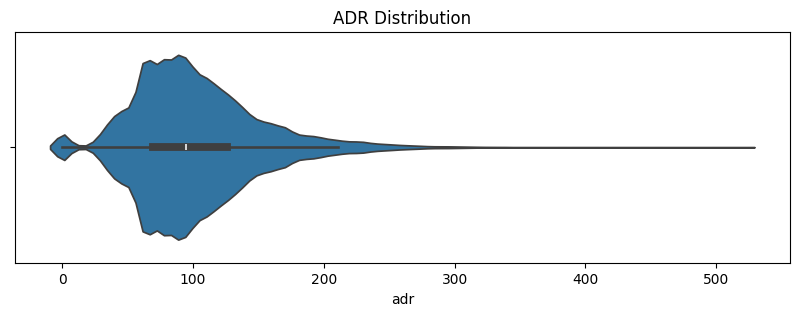

In [105]:
plt.figure(figsize=(10, 3))
sns.violinplot(x=df["adr"])
plt.title("ADR Distribution")
plt.show()

## 8. Análisis univariado de variables categóricas
Realizar gráficos de barras para analizar la frecuencia de las variables categóricas.

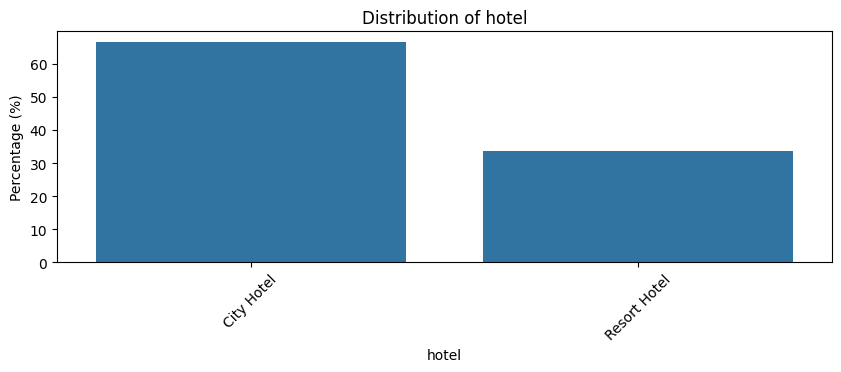

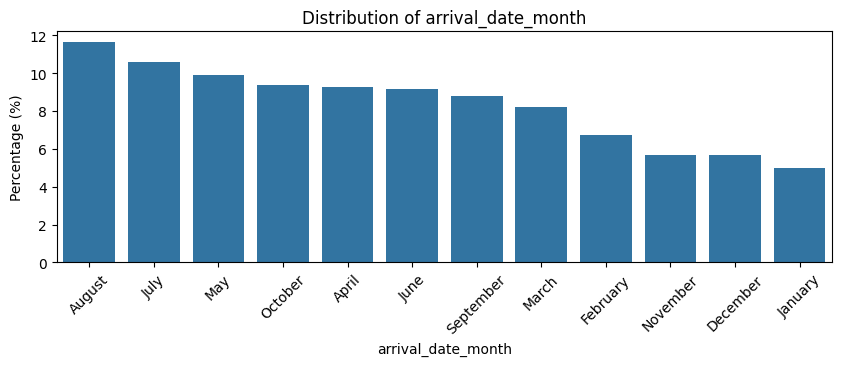

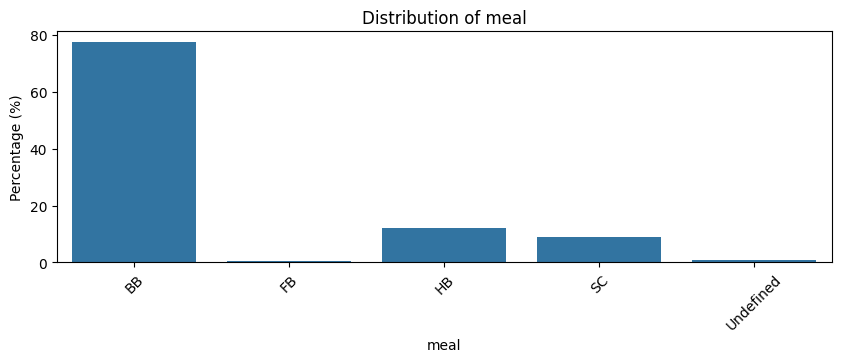

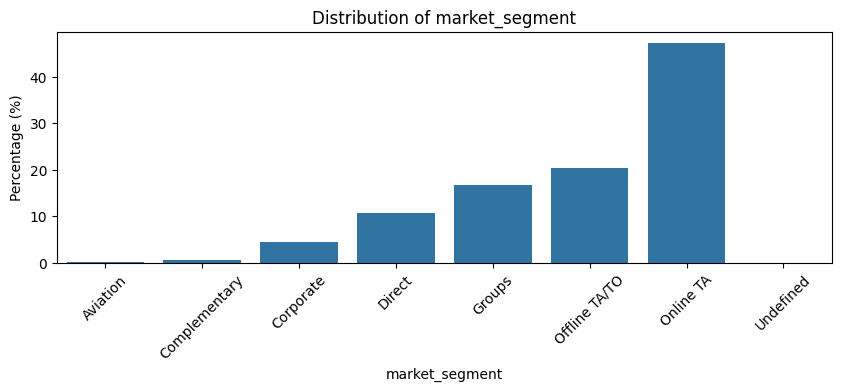

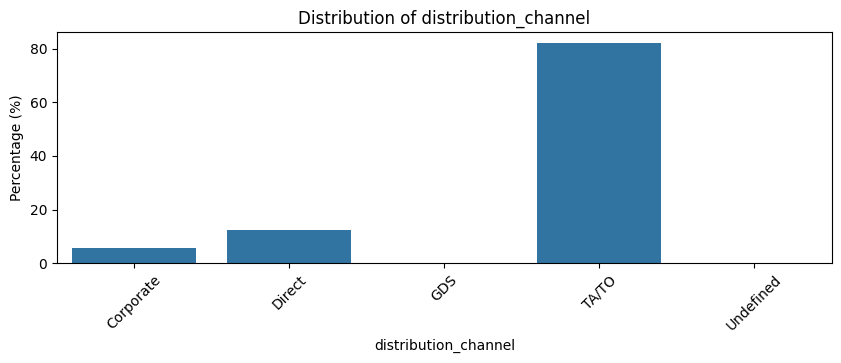

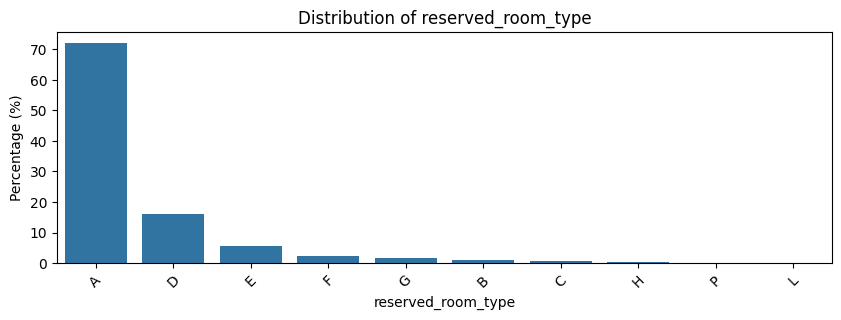

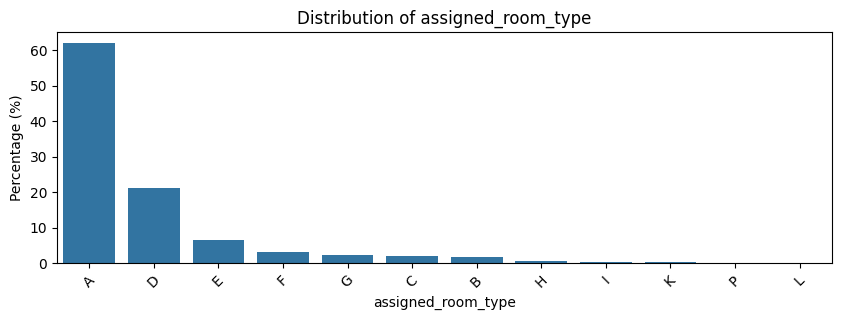

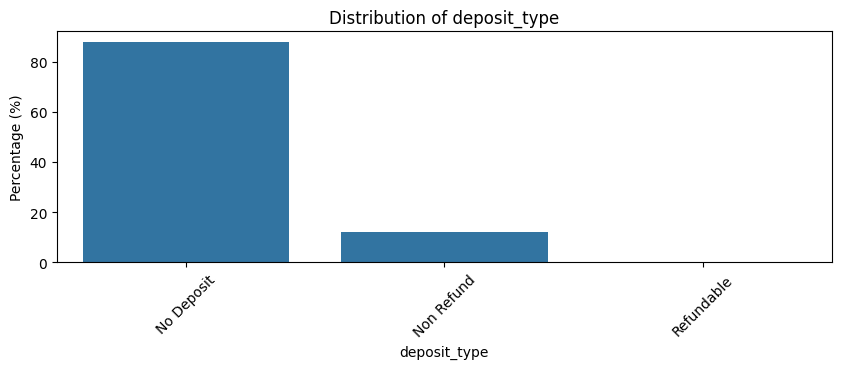

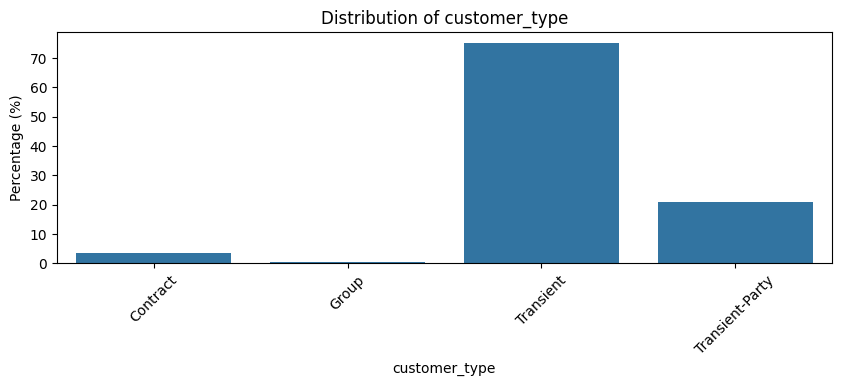

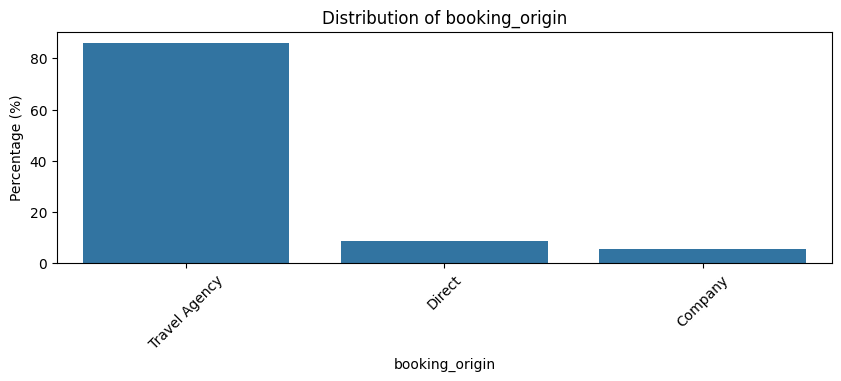

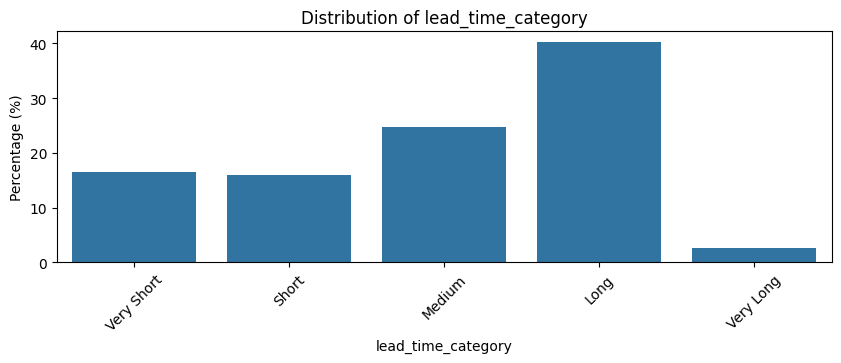

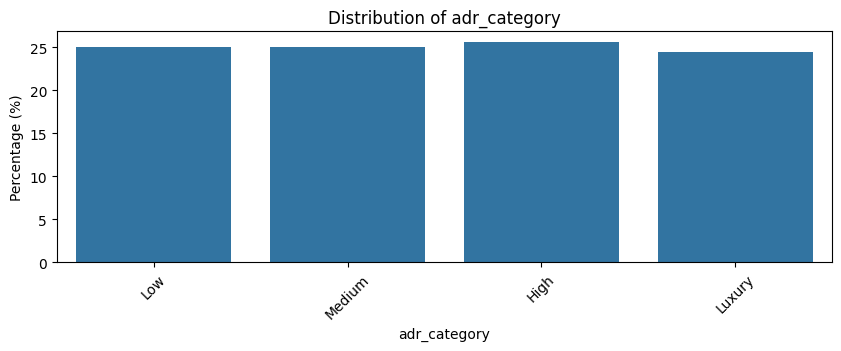

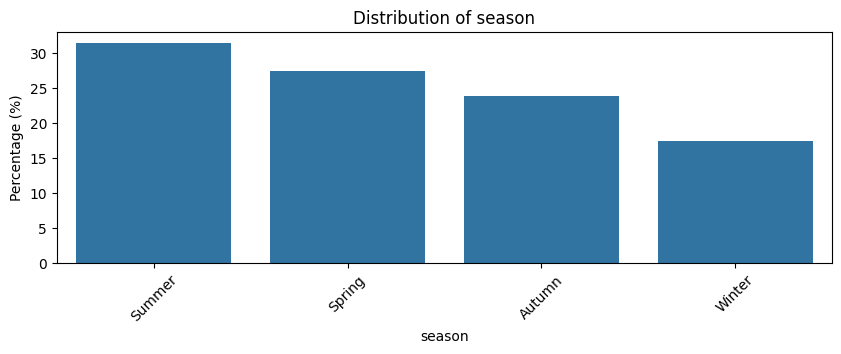

In [ ]:
def plot_categorical(df, col):
    plt.figure(figsize=(10, 3))

    data = df[col].value_counts(normalize=True).mul(100).sort_values(ascending=False)

    sns.barplot(
        x=data.index,
        y=data.values,
    )

    plt.title(f"Distribution of {col}")
    plt.ylabel("Percentage (%)")
    plt.xlabel(col)
    plt.xticks(rotation=45)

    plt.show()


cat_cols = [
    "hotel",
    "arrival_date_month",
    "meal",
    "market_segment",
    "distribution_channel",
    "reserved_room_type",
    "assigned_room_type",
    "deposit_type",
    "customer_type",
    "booking_origin",
    "lead_time_category",
    "adr_category",
    "season",
]

for col in cat_cols:
    plot_categorical(df, col)

## 9. Análisis bivariado entre variables
### 9.1 Cancelaciones por hotel

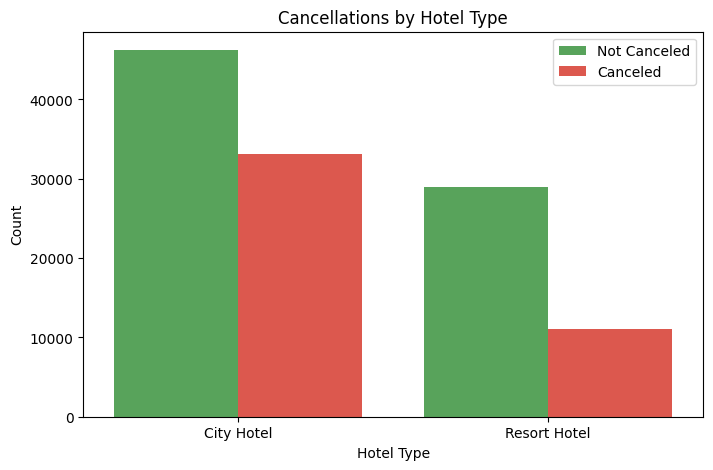

In [121]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="hotel", hue="is_canceled", palette=["#4CAF50", "#F44336"])

plt.title("Cancellations by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Count")
plt.legend(["Not Canceled", "Canceled"])
plt.show()

Se observa visualmente que las barras rojas (canceladas) son proporcionalmente más altas en el "City Hotel". Esto sugiere que el público urbano tiene una flexibilidad o volatilidad de planes mayor que el cliente de "Resort Hotel".

### 9.2 ADR por hotel

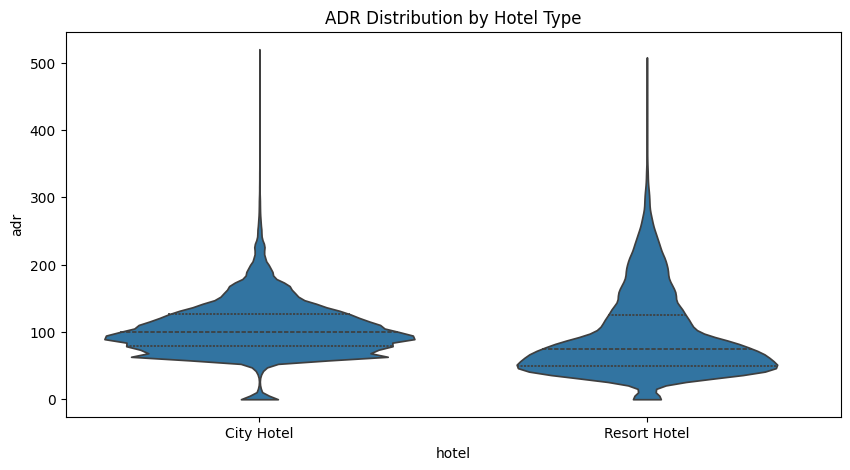

In [160]:
plt.figure(figsize=(10, 5))
sns.violinplot(
    data=df,
    x="hotel",
    y="adr",
    cut=0,
    inner="quartile",
)

plt.title("ADR Distribution by Hotel Type")
plt.show()

### 9.3 Cancelaciones por market segment

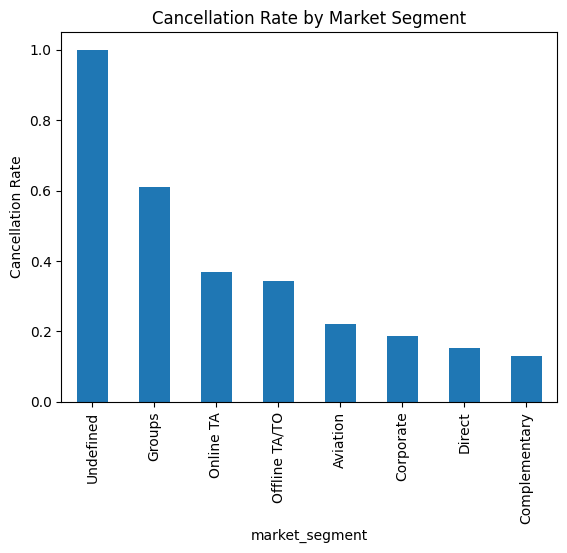

In [145]:
cancel_rate = (
    df.groupby("market_segment")["is_canceled"].mean().sort_values(ascending=False)
)

cancel_rate.plot(kind="bar")

plt.title("Cancellation Rate by Market Segment")
plt.ylabel("Cancellation Rate")
plt.show()

El valor Undefined no representa un segmento real. En este dataset, aparece cuando una reserva se cancela antes de que el sistema pueda asignar un segmento de mercado. Por este motivo, el 100% de las reservas con market_segment = "Undefined" están canceladas. Además, se observa que las agencias de viajes online (TA/TO) y los grupos concentran el riesgo, mientras que la aviación y el sector corporativo son más estables.

In [149]:
print(df[df["market_segment"] == "Undefined"]["is_canceled"].mean())

1.0


### 9.4 Temporada

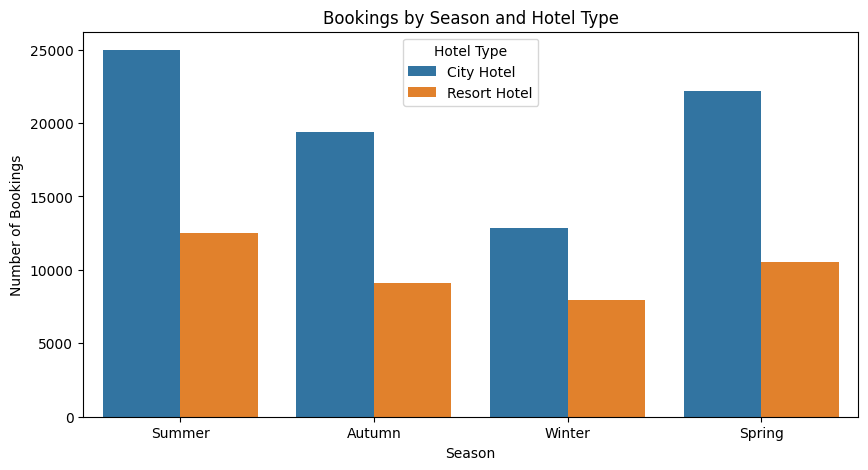

In [158]:
plt.figure(figsize=(10, 5))
sns.countplot(
    data=df,
    x="season",
    hue="hotel",
)

plt.title("Bookings by Season and Hotel Type")
plt.xlabel("Season")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=0)
plt.legend(title="Hotel Type")
plt.show()

### 9.5 Origen de las reservas

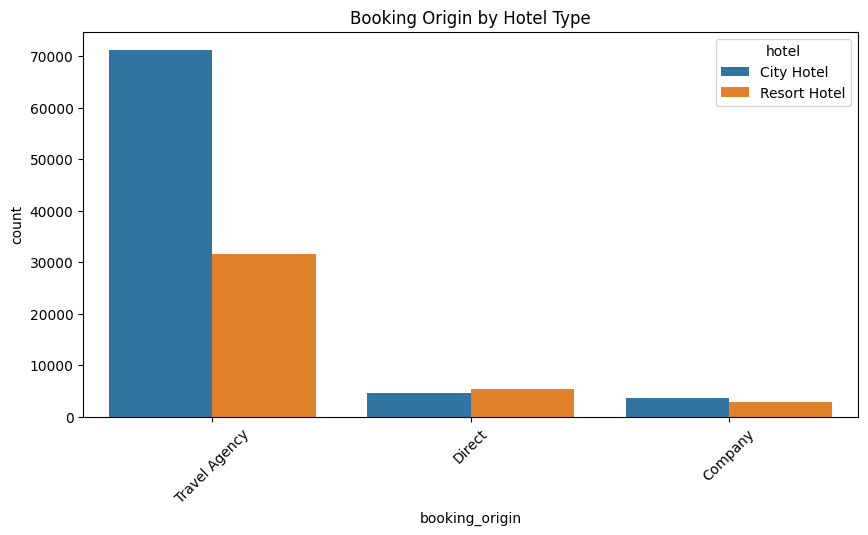

In [167]:
plt.figure(figsize=(10, 5))
sns.countplot(
    data=df,
    x="booking_origin",
    hue="hotel",
    order=df["booking_origin"].value_counts().index,
)

plt.title("Booking Origin by Hotel Type")
plt.xticks(rotation=45)
plt.show()

## 10. Visualización de correlaciones

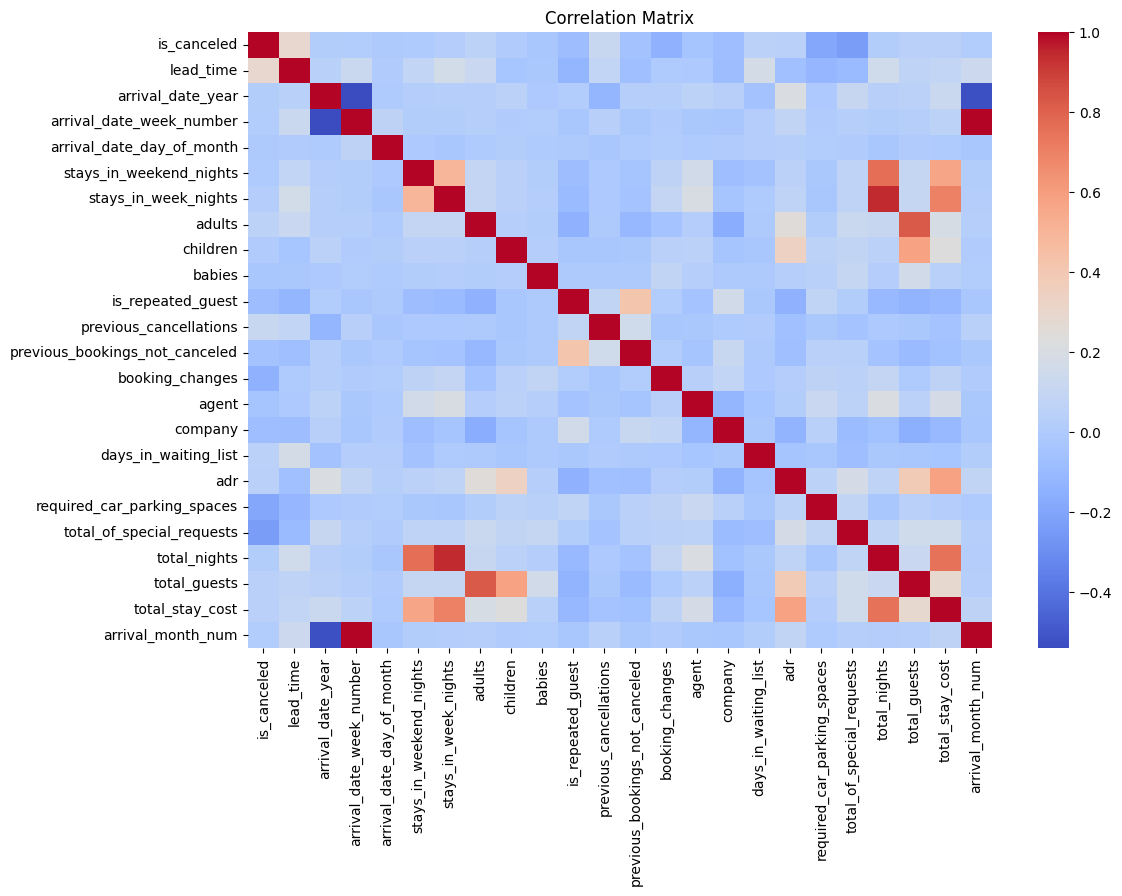

In [163]:
plt.figure(figsize=(12, 8))

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(corr, cmap="coolwarm")

plt.title("Correlation Matrix")
plt.show()

La variable total_stay_cost muestra una correlación lógica fuerte con total_nights y adr. Destaca la correlación positiva entre lead_time e is_canceled, lo que estadísticamente soporta la teoría de que a mayor anticipación, mayor riesgo de cancelación.

## 11. Conclusiones principales

### 11.1 Cancelaciones según hotel y canal de reserva

La tasa general de cancelación ronda el 37%, aunque no afecta igual a todos los hoteles. Los City Hotels concentran muchas más cancelaciones que los Resort Hotels, algo que se observa claramente en los gráficos comparativos.

También se aprecia que las reservas hechas a través de agencias y tour operadores (TA/TO y Groups) tienen tasas de cancelación bastante más altas que las reservas directas. Esto sugiere que depender de intermediarios puede hacer más inestable la ocupación del hotel.

### 11.2 Estacionalidad y comportamiento de precios

El verano es la temporada con mayor volumen de reservas en ambos tipos de hotel. Durante esos meses aumenta tanto la demanda como el precio medio por habitación (ADR).

Los City Hotels muestran precios medios más altos y una mayor presencia de reservas con tarifas elevadas, lo que impacta directamente en el coste total de la estancia (total_stay_cost).

### 11.3 Relación entre antelación y cancelaciones

La mayoría de reservas se realizan con poca o media antelación, aunque existe un grupo importante de clientes que reserva muchos meses antes.

El análisis muestra que cuanto mayor es el lead_time, mayor tiende a ser la probabilidad de cancelación. Las reservas hechas con mucha antelación (“Very Long”) presentan un riesgo especialmente alto, por lo que podrían requerir políticas de depósito o cancelación más estrictas.

## 12. Futuras Mejoras y Siguientes Pasos

- Modelado Predictivo de Cancelaciones: Utilizar las nuevas variables generadas (is_family, lead_time_category, booking_origin) como features para entrenar un modelo de Machine Learning (ej. XGBoost o Regresión Logística) que prediga la probabilidad de cancelación antes de que ocurra.

- Análisis de Series Temporales detallado: Explotar la variable arrival_date de forma cronológica (no solo por temporadas estáticas) para identificar tendencias macroeconómicas interanuales o patrones específicos de días de la semana.

- Optimización de Pricing (Revenue Management): Cruzar la variable room_changed (cambio de habitación asignada vs reservada) con el adr para ver si los upgrades no planificados están haciendo perder dinero al hotel o si se correlacionan con la satisfacción (baja cancelación).